# Demo: Constrained Choice with a Cobb-Douglas Utility
An agent chooses a bundle of two goods to maximize utility subject to a budget. Consider a grocery choice between `apples` ($x_{1}$) and `oranges` ($x_{2}$) with the Cobb-Douglas utility
$$
U(x_{1},x_{2}) = x_{1}^{\alpha}\,x_{2}^{1-\alpha},\qquad 0<\alpha<1,
$$
where good $i$ has unit price $c_{i}>0$ and the agent has a budget $I>0$. The agent solves
$$
\begin{aligned}
\max_{x_{1},x_{2}}\quad & x_{1}^{\alpha}x_{2}^{1-\alpha}\\
\text{subject to}\quad & c_{1}x_{1}+c_{2}x_{2}=I,\\
& x_{1},x_{2}\geq 0.
\end{aligned}
$$
This example computes the optimum two ways, closed form and numerically, verifies the first-order conditions, and shows that the indifference curve is tangent to the budget line at the optimum.

> __Learning Objectives.__
>
> This example connects the Lagrangian conditions to a computed optimum:
> * __Constrained utility maximization:__ Set up and solve the budget-constrained Cobb-Douglas problem for the optimal bundle, both with the closed form $x_{i}^{\star}=\alpha_{i}I/c_{i}$ and numerically with a solver.
> * __First-order optimality conditions:__ Verify that the first-order conditions vanish at the optimum and that the marginal rate of substitution equals the price ratio, $\bar{U}_{1}/\bar{U}_{2}=c_{1}/c_{2}$.
> * __Geometry of the optimum:__ Plot the budget line and the indifference curve through the optimum and show they are tangent at the optimal bundle.

Let's get started.
___

## Theory
The constrained problem is solved with the method of Lagrange multipliers. The Lagrangian is
$$
\mathcal{L}(x_{1},x_{2},\lambda) = x_{1}^{\alpha}x_{2}^{1-\alpha} + \lambda\left(I - c_{1}x_{1} - c_{2}x_{2}\right),
$$
with first-order optimality conditions
$$
\begin{aligned}
\frac{\partial\mathcal{L}}{\partial x_{1}} &= \alpha\,x_{1}^{\alpha-1}x_{2}^{1-\alpha} - \lambda c_{1} = 0,\\
\frac{\partial\mathcal{L}}{\partial x_{2}} &= (1-\alpha)\,x_{1}^{\alpha}x_{2}^{-\alpha} - \lambda c_{2} = 0,\\
\frac{\partial\mathcal{L}}{\partial\lambda} &= I - c_{1}x_{1} - c_{2}x_{2} = 0.
\end{aligned}
$$
For the Cobb-Douglas form with $\alpha_{1}+\alpha_{2}=1$, these conditions have the closed-form solution
$$
x_{1}^{\star} = \frac{\alpha_{1} I}{c_{1}},\qquad x_{2}^{\star} = \frac{\alpha_{2} I}{c_{2}},
$$
which spends the entire budget.
___

## Setup
This example uses functions defined in the `src` directory and a small set of external packages. The `include(...)` call below runs `Include.jl`, which activates the local project environment, loads the packages, and includes our code. The first run may take a few minutes while packages are installed and precompiled.

In [1]:
include("Include.jl");

  Activating project at `~/Desktop/julia_work/CHEME-140-eCornell-Repository/CHEME-140-eCornell-Repository/courses/CHEME-145/module-1`


## Build the Choice Problem
We build a `MySimpleCobbDouglasChoiceProblem` with `build(...)`, passing the preference exponents $\boldsymbol{\alpha}$, the unit prices $\mathbf{c}$, the budget $I$, bounds on each good, and an initial guess for the numerical solver. Here $\alpha=(0.55,0.45)$, so the agent weights apples slightly more than oranges; apples cost \$0.98 and oranges \$1.49; the budget is \$20.

In [2]:
α = [0.55, 0.45];   # preference exponents (sum to 1)
c = [0.98, 1.49];   # unit prices: apples, oranges (USD)
I = 20.0;           # budget (USD)

problem = build(MySimpleCobbDouglasChoiceProblem, (
    α = α,
    c = c,
    I = I,
    initial = 0.1*ones(2),                # initial guess for the solver
    bounds = [0.001 100.0; 0.001 100.0],  # [L U] per good
));

### Solution 1: Closed Form
Because the exponents sum to one, the first-order conditions give the closed form $x_{i}^{\star}=\alpha_{i}I/c_{i}$.

In [3]:
x_closed_form = α .* I ./ c

2-element Vector{Float64}:
 11.224489795918368
  6.040268456375839

### Solution 2: Numerical
The `solve(...)` function maximizes utility subject to the budget with the Ipopt solver. Because the logarithm is increasing, it maximizes $\sum_{i}\alpha_{i}\ln x_{i}$, which has the same maximizer as the product form. The result is a dictionary with keys `argmax` (the optimal bundle), `budget` (resources spent), and `objective_value` (the utility at the optimum).

In [4]:
solution = solve(problem)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



Dict{String, Any} with 3 entries:
  "argmax"          => [11.2245, 6.04027]
  "budget"          => 20.0
  "objective_value" => 8.49311

In [5]:
x_numerical = solution["argmax"];

# do the closed-form and numerical solutions agree?
isapprox(x_closed_form, x_numerical, atol = 1e-4)

true

#### Check 1: Do the first-order conditions vanish at the optimum?
We evaluate the marginal utilities at the optimal bundle, recover the multiplier $\lambda=\bar{U}_{1}/c_{1}$, and confirm the three first-order conditions equal zero.

In [6]:
x̂ = solution["argmax"];
cobb_utility = build(MyCobbDouglasUtilityFunction, (α = α,));
Ū = marginal_utility(cobb_utility, x̂);   # marginal utilities at the optimum
λ = Ū[1]/c[1];                            # Lagrange multiplier

E1 = Ū[1] - λ*c[1];
E2 = Ū[2] - λ*c[2];
E3 = I - (c[1]*x̂[1] + c[2]*x̂[2]);

isapprox.((E1, E2, E3), 0.0, atol = 1e-6)

(true, true, true)

#### Check 2: Does the marginal rate of substitution equal the price ratio?
Dividing the first two first-order conditions removes $\lambda$ and gives the tangency condition
$$
\frac{\bar{U}_{1}}{\bar{U}_{2}} = \frac{c_{1}}{c_{2}}.
$$

In [7]:
isapprox(Ū[1]/Ū[2], c[1]/c[2], atol = 1e-4)

true

___

## Visualize the Budget Line, Indifference Curve, and Optimum
We plot the budget line $c_{1}x_{1}+c_{2}x_{2}=I$, the indifference curve through the optimum at level $U^{\star}$ from `objective_value`, and the optimal bundle. At the optimum the indifference curve is tangent to the budget line.

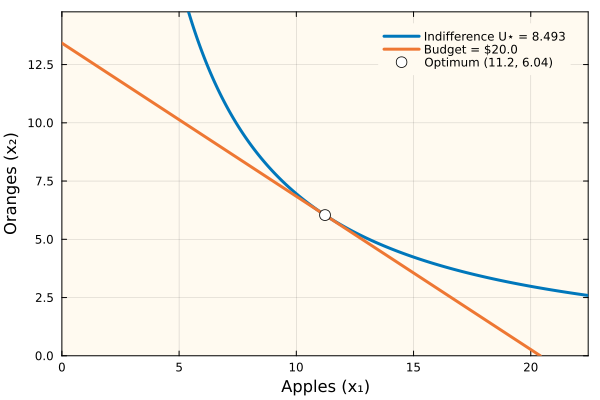

In [8]:
Uopt = solution["objective_value"];
xopt = solution["argmax"];

xlim = [0.001, 1.1*(I/c[1])];
x₁ = range(xlim[1], stop = xlim[2], length = 400) |> collect;

INC = indifference(cobb_utility, Uopt, x₁);   # indifference curve through the optimum
BC  = budget(problem, x₁);                     # budget line

x1_opt = round(xopt[1], sigdigits = 3);
x2_opt = round(xopt[2], sigdigits = 3);

plot(INC[:,1], INC[:,2], label = "Indifference U⋆ = $(round(Uopt, sigdigits=4))", lw = 3, c = colors[1],
    bg = "floralwhite", background_color_outside = "white", framestyle = :box, fg_legend = :transparent);
plot!(BC[:,1], BC[:,2], label = "Budget = \$$(I)", lw = 3, c = colors[3]);
scatter!([xopt[1]], [xopt[2]], ms = 6, c = "white", mec = colors[4],
    label = "Optimum ($(x1_opt), $(x2_opt))");
xlabel!("Apples (x₁)");
ylabel!("Oranges (x₂)");
xlims!(0.0, 1.1*(I/c[1]));
ylims!(0.0, 1.1*(I/c[2]));
current()

___

## Summary
This example solved a budget-constrained Cobb-Douglas choice problem and confirmed the optimum with the first-order conditions. The closed-form and numerical solutions agree, the first-order conditions vanish, and the marginal rate of substitution equals the price ratio, where the indifference curve is tangent to the budget line.

> __Key takeaways:__
>
> 1. __The optimum has a closed form.__ With exponents summing to one, the budget-constrained Cobb-Douglas optimum is $x_{i}^{\star}=\alpha_{i}I/c_{i}$, and it spends the entire budget.
> 2. __The first-order conditions locate the optimum.__ At the optimal bundle the first-order conditions vanish, so each good delivers equal marginal utility per unit cost, $\bar{U}_{i}/c_{i}=\lambda$.
> 3. __The optimum is a tangency.__ The marginal rate of substitution equals the price ratio, $\bar{U}_{1}/\bar{U}_{2}=c_{1}/c_{2}$, so the indifference curve through the optimum is tangent to the budget line.

The closed-form and numerical solutions agree here; the numerical solver extends to utility functions and constraints that have no closed form.
___

### Additional Resources
* Mas-Colell, A., Whinston, M. D., & Green, J. R. (1995). _Microeconomic Theory_. Oxford University Press.
* Varian, H. R. (1992). _Microeconomic Analysis_ (3rd ed.). W. W. Norton.

___